# Tutorial: Creating and Analyzing Multi-Network Energy Systems with Pandaprosumer

## Overview

This tutorial demonstrates how to build a complete energy system that couples multiple networks:
- **Thermal Network** (pandapipes): District heating with heat pump and consumer
- **Electrical Network** (pandapower): Power grid supplying the heat pump
- **Prosumer Networks**: Independent energy system components with their own controllers

The example simulates a district heating system where a heat pump extracts heat from an ambient source and delivers it through a pipe network to a heat consumer. The heat pump's electrical consumption affects the power grid.

## Learning Objectives

By the end of this tutorial, you will understand how to:
1. Import and prepare time-series input data
2. Create prosumer containers with controllers
3. Set up thermal and electrical networks
4. Couple different networks using mapping controllers
5. Run time-series simulations
6. Analyze and visualize results

![title](img/energy_system.png)

## What is an Energy System in Pandaprosumer?

An **Energy System** is a collection of interconnected networks and prosumers that exchange energy and information. Key concepts:

- **Prosumer**: A container holding energy components (heat pump, boiler, etc.) with their controllers
- **Controller**: Defines the behavior and operational limits of a component
- **Network**: Physical infrastructure (pipes, power lines) modeled using pandapipes or pandapower
- **Mapping**: Defines how controllers exchange information (temperatures, mass flows, powers)
- **Coupling Controller**: Special controller that connects networks by reading/writing values between them

The supervisor pattern allows hierarchical control where high-level controllers can modify parameters of lower-level controllers dynamically.

## 1 - Input Data Preparation

First, we import all necessary libraries and load the external time-series data that will drive our simulation.

### Understanding the Input Data

The Excel file contains time-series data for:
- **Tin,evap**: Ambient temperature at the heat pump evaporator inlet (°C)
- **demand_1**: Thermal power demand from the consumer (kW)

These values will be fed to the respective controllers at each time step.

In [166]:
import pandapower
import pandapipes

We define the analysis time series.

In [167]:
start = '2020-01-01 00:00:00'
time_resolution_s = 30

Now we import our demand data and transform it into an appropriate DFData object. All data of an individual element is stored in a dedicated DFData object.

In [168]:
import sys
import os
import pandas as pd
from pandapower.timeseries.data_sources.frame_data import DFData


current_directory = os.getcwd()
parent_directory = os.path.dirname(current_directory)
sys.path.append(parent_directory)

demand_data = pd.read_excel('data/energy_system.xlsx')

end = pd.Timestamp(start) + len(demand_data) * pd.Timedelta(f"00:00:{time_resolution_s}") - pd.Timedelta("00:00:01")

dur = pd.date_range(start=start, end=end, freq=f'{time_resolution_s}s', tz='utc')
demand_data.index = dur
demand_input = DFData(demand_data)

demand_input.df.head(10)

,Tin_cond,Tout_cond,Mass-flow-cond,"Tin,evap",demand_1,demand_2,demand_3,demand_4
2020-01-01 00:00:00+00:00,20.7,75.7,2.0,10.0,100,100.01,100.02,10
2020-01-01 00:00:30+00:00,17.2,71.4,2.2,10.7,100,100.01,100.02,10
2020-01-01 00:01:00+00:00,19.4,70.0,2.5,12.0,100,100.01,100.02,10
2020-01-01 00:01:30+00:00,20.6,67.6,2.6,11.0,200,200.01,200.02,20
2020-01-01 00:02:00+00:00,18.8,74.0,2.3,11.5,200,200.01,200.02,20
2020-01-01 00:02:30+00:00,19.6,67.4,2.1,9.5,200,200.01,200.02,20
2020-01-01 00:03:00+00:00,18.6,69.0,2.0,9.0,200,200.01,200.02,20
2020-01-01 00:03:30+00:00,18.7,73.6,1.9,10.0,300,300.01,300.02,30
2020-01-01 00:04:00+00:00,20.7,67.7,2.0,11.0,300,300.01,300.02,30
2020-01-01 00:04:30+00:00,18.7,73.5,2.3,13.0,300,300.01,300.02,30


We can plot the evolution of the demand from the Excel file.

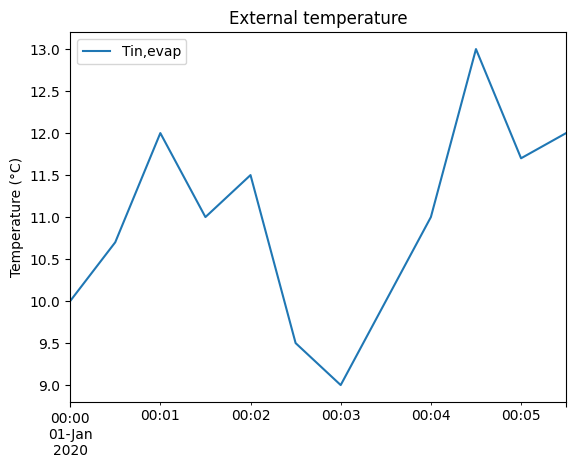

In [169]:
import matplotlib.pyplot as plt

demand_input.df.plot(y='Tin,evap')
plt.title("External temperature")
plt.ylabel("Temperature (°C)")
plt.show()

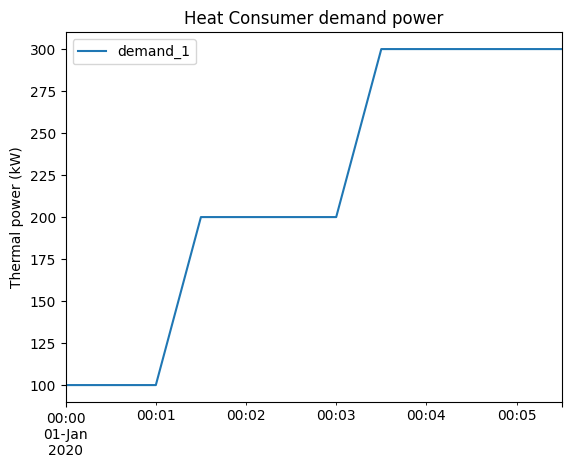

In [170]:
demand_input.df.plot(y='demand_1')
plt.title("Heat Consumer demand power")
plt.ylabel("Thermal power (kW)")
plt.show()

## 2 - CREATING ELEMENTS OF THE NETWORK:

### Creating the Thermal Network (Pandapipes)

We create a simple district heating network with:
- 4 junctions (connection points)
- 2 pipes forming a loop
- 1 circulation pump (maintains flow and pressure)
- 1 heat consumer (extracts thermal energy)

The network operates with water as the fluid medium.

We use the transient calculation mode, specifying the timestep of the simulation.

In [171]:
def _create_pipes_network(time_resolution_s):
    net = pandapipes.create_empty_network(fluid="water", name='net_pipes')
    t_amb_k = 293

    # Create junctions
    j0 = pandapipes.create_junction(net, pn_bar=10, tfluid_k=350, geodata=(0, 1))
    j1 = pandapipes.create_junction(net, pn_bar=10, tfluid_k=350, geodata=(2, 1))
    j2 = pandapipes.create_junction(net, pn_bar=10, tfluid_k=350, geodata=(2, 0))
    j3 = pandapipes.create_junction(net, pn_bar=10, tfluid_k=350, geodata=(0, 0))

    # Create branched elements
    pandapipes.create_pipes_from_parameters(net, from_junctions=[j0, j2], to_junctions=[j1, j3], length_km=.1,
                                            diameter_m=0.05, u_w_per_m2k=10, text_k=t_amb_k)

    pandapipes.create_circ_pump_const_pressure(net, return_junction=j3, flow_junction=j0,
                                               p_flow_bar=10, plift_bar=5, t_flow_k=350,
                                               name='pump_hp_coupling')

    pandapipes.create_heat_consumer(net, from_junction=j1, to_junction=j2,
                                    qext_w=100e3, controlled_mdot_kg_per_s=3,
                                    name='heat_consumer_demand_coupling')

    pandapipes.set_user_pf_options(net, ambient_temperature=t_amb_k, mode='bidirectional',
                                   transient=True, dt=time_resolution_s)

    return net

### Creating the Electrical Network (Pandapower)

A simple power grid with:
- 2 buses (electrical nodes)
- 1 external grid connection (infinite power source)
- 1 transmission line
- 1 load (will represent the heat pump's electrical consumption)

This network will track how the heat pump affects the electrical system.

In [172]:
def _create_power_network():
    net = pandapower.create_empty_network(name='net_power')
    b1 = pandapower.create_bus(net, vn_kv=20.)
    b2 = pandapower.create_bus(net, vn_kv=20.)
    pandapower.create_line(net, from_bus=b1, to_bus=b2, length_km=2.5, std_type="NAYY 4x50 SE")
    pandapower.create_ext_grid(net, bus=b1)
    pandapower.create_load(net, bus=b2, p_mw=1., name='load_hp_coupling')
    return net

### Creating the Producer Prosumer

The producer prosumer contains:
1. **Const Profile Controller**: Feeds ambient temperature from the Excel file
2. **Heat Pump Controller**: Models a vapor-compression heat pump with:
   - Carnot efficiency of 50%
   - Temperature pinch of 5°C
   - Evaporator temperature approach of 8°C
   - Maximum compressor power of 1 MW

The mapping connects the ambient temperature input to the heat pump's evaporator inlet.

In [173]:
from pandaprosumer.create_controlled import *


def _create_prosumer_prod(hp_level):
    prosumer = create_empty_prosumer_container(name='prosumer_prod', check_order=False)
    data_source = demand_input
    period = create_period(prosumer, time_resolution_s, start, end, 'utc', 'default')

    cp_input_columns = ["Tin,evap"]
    cp_result_columns = ["Tin,evap"]

    hp_params = {'carnot_efficiency': 0.5,
                 'pinch_c': 5,
                 'delta_t_evap_c': 8,
                 'max_p_comp_kw': 1000e3}

    cp_controller_index = create_controlled_const_profile(prosumer, cp_input_columns, cp_result_columns,
                                                          data_source, period, level=0, order=0)

    hp_controller_index = create_controlled_heat_pump(prosumer, period=period, name='hp_controller',
                                                      level=hp_level, order=0, **hp_params)

    GenericMapping(container=prosumer,
                   initiator_id=cp_controller_index,
                   initiator_column="Tin,evap",
                   responder_id=hp_controller_index,
                   responder_column="t_evap_in_c",
                   order=0)

    return prosumer

### Creating the Consumer Prosumer

The consumer prosumer contains:
1. **Const Profile Controller**: Feeds demand power from the Excel file
2. **Heat Exchanger Controller**: Primary-secondary heat exchanger with nominal operating conditions
3. **Heat Demand Controller**: Represents the building's heating demand with inlet/outlet temperature setpoints

Mappings connect:
- Demand power → Heat demand controller
- Heat exchanger fluid properties → Heat demand controller

In [174]:
from pandaprosumer.mapping import GenericMapping, FluidMixMapping


def _create_prosumer_dmd(level):
    prosumer = create_empty_prosumer_container(name='prosumer_dmd', check_order=False)
    data_source = demand_input
    period = create_period(prosumer, time_resolution_s, start, end, 'utc', 'default')

    cp_input_columns = ["demand_1"]
    cp_result_columns = ["demand_kw"]

    hx_params = {'t_1_in_nom_c': 45,
                 't_1_out_nom_c': 30,
                 't_2_in_nom_c': 20,
                 't_2_out_nom_c': 40,
                 'mdot_2_nom_kg_per_s': 3.58}

    hd_params = {'t_in_set_c': 40,
                 't_out_set_c': 20}

    cp_controller_index = create_controlled_const_profile(prosumer, cp_input_columns, cp_result_columns,
                                                          data_source, period, level=0, order=0)

    hx_controller_index = create_controlled_heat_exchanger(prosumer, period=period, name='hx_controller',
                                                           level=level, order=0, **hx_params)
    hd_controller_index = create_controlled_heat_demand(prosumer, period=period, name='hd_controller',
                                                        level=level, order=1, **hd_params)

    GenericMapping(container=prosumer,
                   initiator_id=cp_controller_index,
                   initiator_column="demand_kw",
                   responder_id=hd_controller_index,
                   responder_column="q_demand_kw",
                   order=0)

    FluidMixMapping(container=prosumer,
                    initiator_id=hx_controller_index,
                    responder_id=hd_controller_index,
                    order=0)

    return prosumer

### Assembling the Energy System

The energy system combines:
- The thermal network (pipes)
- The electrical network (power)
- The producer prosumer (heat pump)
- The consumer prosumer (heat exchanger + demand)

All components share the same time resolution and simulation period.

In [175]:
from pandaprosumer.energy_system import create_empty_energy_system, add_net_to_energy_system, \
    add_pandaprosumer_to_energy_system


def _create_energy_system(nets, prosumers, name="test_energy_system"):
    energy_system = create_empty_energy_system(name=name)
    sample_prosumer_period = prosumers[0].period
    create_period(energy_system, sample_prosumer_period.iloc[0]["resolution_s"],
                  sample_prosumer_period.iloc[0]["start"],
                  sample_prosumer_period.iloc[0]["end"],
                  timezone=sample_prosumer_period.iloc[0]["timezone"],
                  name=sample_prosumer_period.iloc[0]["name"])
    for net in nets:
        add_net_to_energy_system(energy_system, net, net_name=net.name)
    for prosumer in prosumers:
        add_pandaprosumer_to_energy_system(energy_system, prosumer, pandaprosumer_name=prosumer.name)
    return energy_system

In [176]:
net_pipes = _create_pipes_network(time_resolution_s)
net_power = _create_power_network()
prosumer_prod = _create_prosumer_prod(hp_level=2)
prosumer_dmd = _create_prosumer_dmd(level=3)
energy_system = _create_energy_system([net_pipes, net_power], [prosumer_prod, prosumer_dmd])

### Output Writers Setup

Output writers log network variables at each time step for post-processing:
- Thermal network: Temperatures, mass flows, heat powers, velocities
- Electrical network: Load power consumption

These logged values will be used for results analysis and plotting.

In [177]:
from pandapower.timeseries import OutputWriter

sample_prosumer_period = prosumer_prod.period
ow_time_steps = pd.date_range(sample_prosumer_period.iloc[0]["start"], sample_prosumer_period.iloc[0]["end"],
                              freq='%ss' % int(sample_prosumer_period.iloc[0]["resolution_s"]),
                              tz=sample_prosumer_period.iloc[0]["timezone"])
OutputWriter(net_pipes, ow_time_steps, log_variables=[
    ('res_circ_pump_pressure', 't_from_k'),
    ('res_circ_pump_pressure', 't_to_k'),
    ('res_circ_pump_pressure', 'mdot_from_kg_per_s'),
    ('res_heat_consumer', 't_from_k'),
    ('res_heat_consumer', 't_to_k'),
    ('res_heat_consumer', 'mdot_from_kg_per_s'),
    ('heat_consumer', 'qext_w'),
    ('res_pipe', 'v_mean_m_per_s')
])
OutputWriter(net_power, ow_time_steps, log_variables=[('res_load', 'p_mw')])


OutputWriter: writes output to 'None' and logs:
'res_load.p_mw'

## 3 - Creating Network Coupling Controllers

**Network Coupling Controllers** are the bridge between networks and prosumers. They:
- **Read** values from network elements (temperatures, flows)
- **Write** values to network elements (heat inputs, flow rates)
- Enable bidirectional information exchange

We create three coupling controllers for the thermal network and one for the electrical network.

### Thermal Network Couplings

1. **Pump Write Controller**: Receives temperature and mass flow from the heat pump and writes them to the circulation pump
2. **Consumer Read Controller**: Reads temperature and mass flow at the heat consumer location
3. **Consumer Write Controller**: Receives heat demand and flow rate from the consumer prosumer

In [179]:
from pandapower import get_element_index

pump_elmt_index = get_element_index(net_pipes, 'circ_pump_pressure', 'pump_hp_coupling')
consumer_elmt_index = get_element_index(net_pipes, 'heat_consumer', 'heat_consumer_demand_coupling')

In [180]:
nc_write_pump_index = create_controlled_network_coupling(net_pipes,
                                                         pump_elmt_index,
                                                         element_name='circ_pump_pressure',
                                                         temp_fluid_map_input_col=['t_flow_k'],
                                                         mdot_fluid_map_input_col=['mdot_flow_kg_per_s'],
                                                         level=4,
                                                         order=0)

nc_read_dmd_index = create_controlled_network_coupling(net_pipes,
                                                       consumer_elmt_index,
                                                       element_name='heat_consumer',
                                                       result_columns=['t_from_k', 't_to_k',
                                                                       'mdot_from_kg_per_s'],
                                                       temp_fluid_map_output_idx=0,
                                                       mdot_fluid_map_output_idx=2,
                                                       level=1,
                                                       order=2)

nc_write_dmd_index = create_controlled_network_coupling(net_pipes,
                                                        consumer_elmt_index,
                                                        element_name='heat_consumer',
                                                        input_columns=['qext_w', 'controlled_mdot_kg_per_s'],
                                                        level=4,
                                                        order=2)

### Electrical Network Coupling

The load write controller receives the heat pump's electrical power consumption and updates the load in the power network.

In [181]:
load_elmt_index = get_element_index(net_power, 'load', 'load_hp_coupling')

In [182]:
nc_write_load_index = create_controlled_network_coupling(net_power,
                                                         load_elmt_index,
                                                         element_name='load',
                                                         input_columns=['p_mw'],
                                                         level=5, order=0)

## 4 - Creating Energy System Mappings

**Energy System Mappings** connect controllers across different networks:

1. **Producer → Thermal Network**: Heat pump condenser output → Pump inlet conditions
2. **Thermal Network → Consumer**: Pipe network outlet → Heat exchanger inlet
3. **Consumer → Thermal Network**: Heat exchanger power → Consumer element heat input
4. **Consumer → Thermal Network**: Heat exchanger flow → Consumer element mass flow
5. **Producer → Electrical Network**: Compressor power → Electrical load

These mappings enable the co-simulation of all networks in a synchronized manner.

First, we get the indexes within their prosumers of the controllers to map:

In [183]:
from pandapower.control import get_controller_index

hp_ctrl_index = get_controller_index(prosumer_prod, parameters={'name': 'hp_controller'})
hx_ctrl_index = get_controller_index(prosumer_dmd, parameters={'name': 'hx_controller'})

Then, we create the EnergySystemMapping between the prosumers controllers and the Network Coupling controllers in the pandapipes network:

In [184]:
from pandaprosumer.mapping import FluidMixEnergySystemMapping, GenericEnergySystemMapping

FluidMixEnergySystemMapping(container=prosumer_prod,
                            initiator_id=hp_ctrl_index,
                            responder_net=net_pipes,
                            responder_id=nc_write_pump_index,
                            order=0,
                            no_chain=False)

FluidMixEnergySystemMapping(container=net_pipes,
                            initiator_id=nc_read_dmd_index,
                            responder_net=prosumer_dmd,
                            responder_id=hx_ctrl_index,
                            order=0,
                            no_chain=True)

GenericEnergySystemMapping(container=prosumer_dmd,
                           initiator_id=hx_ctrl_index,
                           initiator_column='q_exchanged_kw',
                           responder_net=net_pipes,
                           responder_id=nc_write_dmd_index,
                           responder_column='qext_w',
                           order=0,
                           conversion_function=lambda q: q * 1000)

GenericEnergySystemMapping(container=prosumer_dmd,
                           initiator_id=hx_ctrl_index,
                           initiator_column='mdot_1_kg_per_s',
                           responder_net=net_pipes,
                           responder_id=nc_write_dmd_index,
                           responder_column='controlled_mdot_kg_per_s',
                           order=1)

Finally, we do the same for the electrical network:

In [185]:
GenericEnergySystemMapping(container=prosumer_prod,
                           initiator_id=hp_ctrl_index,
                           initiator_column='p_comp_kw',
                           responder_net=net_power,
                           responder_id=nc_write_load_index,
                           responder_column='p_mw',
                           order=0,
                           conversion_function=lambda p: p / 1000)

## 5 - Running the Time-Series Simulation

The simulation executes sequentially:
1. Read input data for current time step
2. Update controller parameters via mappings
3. Solve thermal network (pandapipes)
4. Solve electrical network (pandapower)
5. Exchange results between networks via coupling controllers
6. Advance to next time step

The `transient=True` option enables dynamic thermal behavior in the pipe network.

In [186]:
from pandaprosumer.energy_system.timeseries.run_time_series_energy_system import \
run_timeseries as run_time_series_system

period = 0
run_time_series_system(energy_system,
                       period_index=period, continue_on_divergence=False, verbose=True,
                       transient=True, dt=time_resolution_s)

100%|██████████| 12/12 [00:00<00:00, 17.29it/s]


## 6 - Analyzing Results

After simulation, results are stored in:
- **prosumer.time_series**: Contains all controller outputs over time
- **net.output_writer**: Contains network element results over time

We can now extract and analyze these results to understand system behavior.

### Understanding the Time-Series Data Structure

Each controller stores its results in a DataFrame accessible via:
- `prosumer.time_series.data_source.loc[controller_index].df`

The index represents the controller number (0 = const profile, 1 = heat pump/heat exchanger, etc.).

Before plotting we have to look at the resulting dataframe to see which quantity (column) do we want to plot.

Access the results of the heat pump, gas boiler and heat demand:

In [187]:
prosumer_dmd.time_series

,name,element,element_index,period_index,data_source
0,hx_controller,heat_exchanger,0.0,0.0,DFData
1,hd_controller,heat_demand,0.0,0.0,DFData


In [188]:
prosumer_dmd.time_series.data_source.loc[0].df.head(10)

,q_exchanged_kw,mdot_1_kg_per_s,t_1_in_c,t_1_out_c,mdot_2_kg_per_s,t_2_in_c,t_2_out_c
2020-01-01 00:00:00+00:00,99.936538,3.0,76.623180,68.676716,1.196146,20.0,40.0
2020-01-01 00:00:30+00:00,99.936535,3.0,76.469575,68.522916,1.196146,20.0,40.0
2020-01-01 00:01:00+00:00,99.936530,3.0,76.247388,68.300448,1.196146,20.0,40.0
2020-01-01 00:01:30+00:00,199.758465,3.0,76.178370,60.284313,2.392292,20.0,40.0
2020-01-01 00:02:00+00:00,199.758627,3.0,76.156930,60.262819,2.392292,20.0,40.0
2020-01-01 00:02:30+00:00,199.758677,3.0,76.150269,60.256142,2.392292,20.0,40.0
2020-01-01 00:03:00+00:00,199.758693,3.0,76.148200,60.254067,2.392292,20.0,40.0
2020-01-01 00:03:30+00:00,299.493104,3.0,76.147558,52.306355,3.588437,20.0,40.0
2020-01-01 00:04:00+00:00,299.493106,3.0,76.147358,52.306155,3.588437,20.0,40.0
2020-01-01 00:04:30+00:00,299.493107,3.0,76.147296,52.306093,3.588437,20.0,40.0


In [189]:
prosumer_dmd.time_series.data_source.loc[1].df.head(10)

,q_received_kw,q_uncovered_kw,mdot_kg_per_s,t_in_c,t_out_c
2020-01-01 00:00:00+00:00,100.0,0.000000e+00,1.196146,40.0,20.0
2020-01-01 00:00:30+00:00,100.0,0.000000e+00,1.196146,40.0,20.0
2020-01-01 00:01:00+00:00,100.0,0.000000e+00,1.196146,40.0,20.0
2020-01-01 00:01:30+00:00,200.0,0.000000e+00,2.392292,40.0,20.0
2020-01-01 00:02:00+00:00,200.0,0.000000e+00,2.392292,40.0,20.0
2020-01-01 00:02:30+00:00,200.0,0.000000e+00,2.392292,40.0,20.0
2020-01-01 00:03:00+00:00,200.0,0.000000e+00,2.392292,40.0,20.0
2020-01-01 00:03:30+00:00,300.0,5.684342e-14,3.588437,40.0,20.0
2020-01-01 00:04:00+00:00,300.0,5.684342e-14,3.588437,40.0,20.0
2020-01-01 00:04:30+00:00,300.0,5.684342e-14,3.588437,40.0,20.0


In [190]:
prosumer_prod.time_series

,name,element,element_index,period_index,data_source
0,hp_controller,heat_pump,0.0,0.0,DFData


In [191]:
prosumer_prod.time_series.data_source.loc[0].df.head(10)

,q_cond_kw,p_comp_kw,q_evap_kw,cop,mdot_cond_kg_per_s,t_cond_in_c,t_cond_out_c,mdot_evap_kg_per_s,t_evap_in_c,t_evap_out_c
2020-01-01 00:00:00+00:00,35.581524,13.400704,22.180821,2.655198,3.0,74.021991,76.85,0.660179,10.0,2.0
2020-01-01 00:00:30+00:00,77.423502,28.853886,48.569617,2.683296,3.0,70.694767,76.85,1.445870,10.7,2.7
2020-01-01 00:01:00+00:00,103.342478,37.756393,65.586085,2.737086,3.0,68.632833,76.85,1.953105,12.0,4.0
2020-01-01 00:01:30+00:00,111.989016,41.546348,70.442669,2.695520,3.0,67.944823,76.85,2.097175,11.0,3.0
2020-01-01 00:02:00+00:00,182.578260,67.219658,115.358602,2.716144,3.0,62.325308,76.85,3.434839,11.5,3.5
2020-01-01 00:02:30+00:00,204.725139,77.680215,127.044925,2.635486,3.0,60.561704,76.85,3.780803,9.5,1.5
2020-01-01 00:03:00+00:00,211.680928,80.915780,130.765148,2.616065,3.0,60.007721,76.85,3.891001,9.0,1.0
2020-01-01 00:03:30+00:00,213.866358,80.546287,133.320070,2.655198,3.0,59.833658,76.85,3.968073,10.0,2.0
2020-01-01 00:04:00+00:00,282.095338,104.653397,177.441941,2.695520,3.0,54.397570,76.85,5.282691,11.0,3.0
2020-01-01 00:04:30+00:00,303.530821,109.185594,194.345227,2.779953,3.0,52.688971,76.85,5.788986,13.0,5.0


## 7 - Visualization: Power Balance

The first set of plots shows energy flows through the system:

**Top Left**: Thermal power comparison
- Heat pump condenser output
- Pipe network consumer input
- Actual power received by demand

**Top Right**: Electrical power consumption
- Heat pump compressor power
- Power network load

**Bottom Left**: Pipe network temperatures
- Supply and return temperatures at pump and consumer

**Bottom Right**: Prosumer temperatures
- Heat pump condenser temperatures
- Heat exchanger primary side temperatures

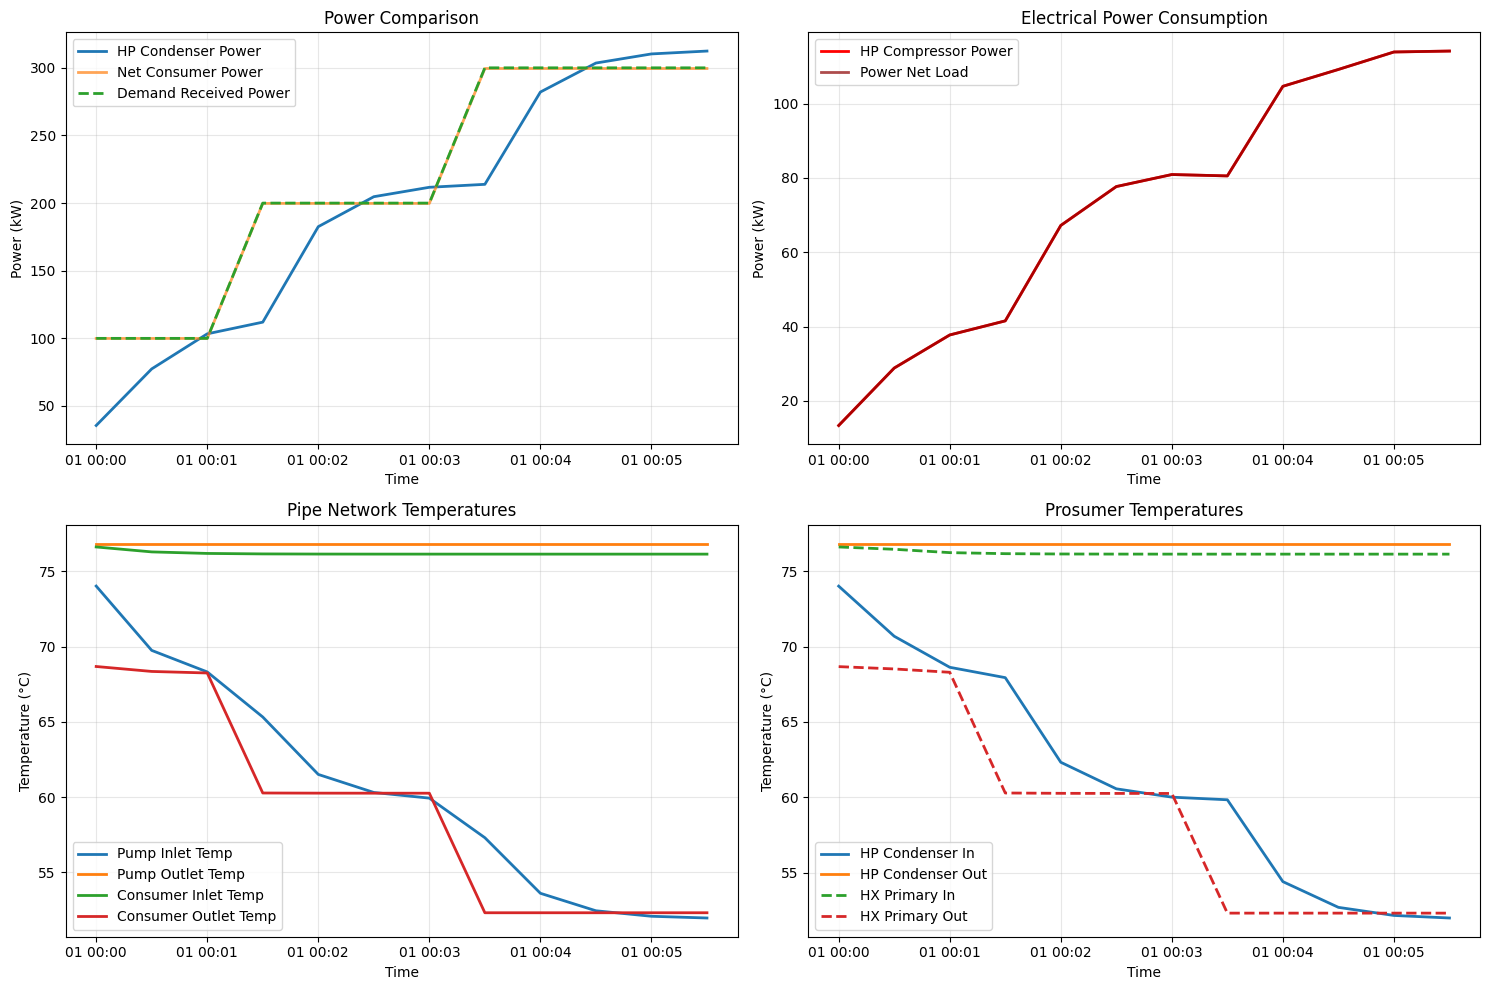

In [192]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Power comparison
axes[0, 0].plot(prosumer_prod.time_series.data_source.loc[0].df.index,
                prosumer_prod.time_series.data_source.loc[0].df['q_cond_kw'],
                label='HP Condenser Power', linewidth=2)
axes[0, 0].plot(net_pipes.output_writer.object.loc[0].output['heat_consumer.qext_w'].index,
                net_pipes.output_writer.object.loc[0].output['heat_consumer.qext_w'] / 1000,
                label='Net Consumer Power', linewidth=2, alpha=0.7)
axes[0, 0].plot(prosumer_dmd.time_series.data_source.loc[1].df.index,
                prosumer_dmd.time_series.data_source.loc[1].df['q_received_kw'],
                label='Demand Received Power', linewidth=2, linestyle='--')
axes[0, 0].set_xlabel('Time')
axes[0, 0].set_ylabel('Power (kW)')
axes[0, 0].set_title('Power Comparison')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# HP compressor power
axes[0, 1].plot(prosumer_prod.time_series.data_source.loc[0].df.index,
                prosumer_prod.time_series.data_source.loc[0].df['p_comp_kw'],
                label='HP Compressor Power', color='red', linewidth=2)
axes[0, 1].plot(net_power.output_writer.object.loc[0].output['res_load.p_mw'].index,
                net_power.output_writer.object.loc[0].output['res_load.p_mw'] * 1000,
                label='Power Net Load', color='darkred', linewidth=2, alpha=0.7)
axes[0, 1].set_xlabel('Time')
axes[0, 1].set_ylabel('Power (kW)')
axes[0, 1].set_title('Electrical Power Consumption')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Temperature in pipes net
axes[1, 0].plot(net_pipes.output_writer.object.loc[0].output['res_circ_pump_pressure.t_from_k'].index,
                net_pipes.output_writer.object.loc[0].output['res_circ_pump_pressure.t_from_k'] - 273.15,
                label='Pump Inlet Temp', linewidth=2)
axes[1, 0].plot(net_pipes.output_writer.object.loc[0].output['res_circ_pump_pressure.t_to_k'].index,
                net_pipes.output_writer.object.loc[0].output['res_circ_pump_pressure.t_to_k'] - 273.15,
                label='Pump Outlet Temp', linewidth=2)
axes[1, 0].plot(net_pipes.output_writer.object.loc[0].output['res_heat_consumer.t_from_k'].index,
                net_pipes.output_writer.object.loc[0].output['res_heat_consumer.t_from_k'] - 273.15,
                label='Consumer Inlet Temp', linewidth=2)
axes[1, 0].plot(net_pipes.output_writer.object.loc[0].output['res_heat_consumer.t_to_k'].index,
                net_pipes.output_writer.object.loc[0].output['res_heat_consumer.t_to_k'] - 273.15,
                label='Consumer Outlet Temp', linewidth=2)
axes[1, 0].set_xlabel('Time')
axes[1, 0].set_ylabel('Temperature (°C)')
axes[1, 0].set_title('Pipe Network Temperatures')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Temperature in prosumers
axes[1, 1].plot(prosumer_prod.time_series.data_source.loc[0].df.index,
                prosumer_prod.time_series.data_source.loc[0].df['t_cond_in_c'],
                label='HP Condenser In', linewidth=2)
axes[1, 1].plot(prosumer_prod.time_series.data_source.loc[0].df.index,
                prosumer_prod.time_series.data_source.loc[0].df['t_cond_out_c'],
                label='HP Condenser Out', linewidth=2)
axes[1, 1].plot(prosumer_dmd.time_series.data_source.loc[0].df.index,
                prosumer_dmd.time_series.data_source.loc[0].df['t_1_in_c'],
                label='HX Primary In', linewidth=2, linestyle='--')
axes[1, 1].plot(prosumer_dmd.time_series.data_source.loc[0].df.index,
                prosumer_dmd.time_series.data_source.loc[0].df['t_1_out_c'],
                label='HX Primary Out', linewidth=2, linestyle='--')
axes[1, 1].set_xlabel('Time')
axes[1, 1].set_ylabel('Temperature (°C)')
axes[1, 1].set_title('Prosumer Temperatures')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

We can check that the water velocity in the pipes is 1.57 m/s, the pipes are 100 meters long, and the timestep is 30 seconds.
Using pandapipes transient calculations, the Pump Inlet temperature will follow the Heat Consumer outlet temperature, but with a delay and a smoothing of the curve dur to the heat transportation time, as we can see in the plots.


In [193]:
net_pipes.output_writer.object.loc[0].output['res_pipe.v_mean_m_per_s']

,0,1
2020-01-01 00:00:00+00:00,1.569174,1.564059
2020-01-01 00:00:30+00:00,1.569012,1.561912
2020-01-01 00:01:00+00:00,1.568962,1.561232
2020-01-01 00:01:30+00:00,1.568947,1.556474
2020-01-01 00:02:00+00:00,1.568942,1.554858
2020-01-01 00:02:30+00:00,1.568940,1.554354
2020-01-01 00:03:00+00:00,1.568940,1.554196
2020-01-01 00:03:30+00:00,1.568940,1.550086
2020-01-01 00:04:00+00:00,1.568940,1.548668
2020-01-01 00:04:30+00:00,1.568940,1.548240


## 8 - Visualization: Mass Flows and Efficiency

**Mass Flow Rates**: Shows consistency of flow rates across:
- Pipe network pump and consumer
- Heat pump condenser
- Heat exchanger primary side

**COP (Coefficient of Performance)**: Heat pump efficiency metric
- Ratio of thermal output to electrical input
- Higher COP indicates better performance
- Varies with operating conditions (temperatures, loads)

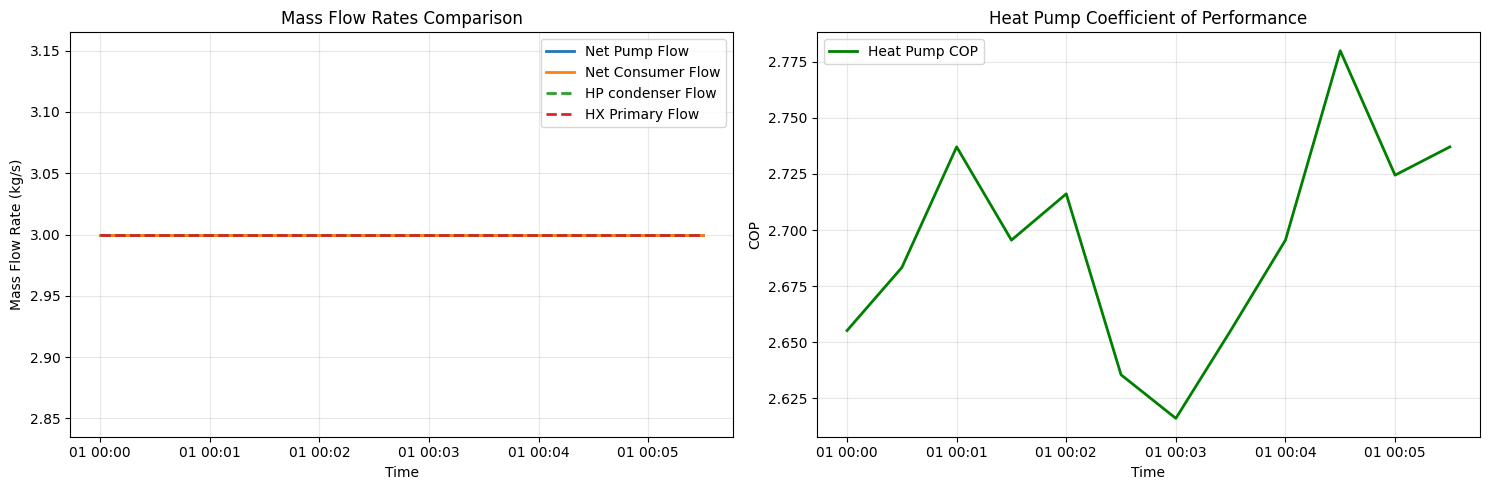

In [194]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Mass flow rates comparison
axes[0].plot(net_pipes.output_writer.object.loc[0].output['res_circ_pump_pressure.mdot_from_kg_per_s'].index,
             net_pipes.output_writer.object.loc[0].output['res_circ_pump_pressure.mdot_from_kg_per_s'],
             label='Net Pump Flow', linewidth=2)
axes[0].plot(net_pipes.output_writer.object.loc[0].output['res_heat_consumer.mdot_from_kg_per_s'].index,
             net_pipes.output_writer.object.loc[0].output['res_heat_consumer.mdot_from_kg_per_s'],
             label='Net Consumer Flow', linewidth=2)
axes[0].plot(prosumer_prod.time_series.data_source.loc[0].df.index,
             prosumer_prod.time_series.data_source.loc[0].df['mdot_cond_kg_per_s'],
             label='HP condenser Flow', linewidth=2, linestyle='--')
axes[0].plot(prosumer_dmd.time_series.data_source.loc[0].df.index,
             prosumer_dmd.time_series.data_source.loc[0].df['mdot_1_kg_per_s'],
             label='HX Primary Flow', linewidth=2, linestyle='--')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Mass Flow Rate (kg/s)')
axes[0].set_title('Mass Flow Rates Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# COP and efficiency
axes[1].plot(prosumer_prod.time_series.data_source.loc[0].df.index,
             prosumer_prod.time_series.data_source.loc[0].df['cop'],
             label='Heat Pump COP', linewidth=2, color='green')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('COP')
axes[1].set_title('Heat Pump Coefficient of Performance')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Key Insights from Results

1. **Energy Balance**: Heat pump output ≈ Pipe network transport ≈ Consumer demand (accounting for losses)
2. **Temperature Cascade**: Heat pump → Pipes → Heat exchanger → Demand (each with temperature drop)
3. **Flow Continuity**: Mass flow rate remains consistent through closed loop
4. **COP Variation**: Heat pump efficiency changes with ambient temperature and load
5. **Electrical Impact**: Heat pump operation directly affects power grid load
